Start of the Code

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import least_squares

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import necessary Files

In [69]:
data_path = "/content/drive/MyDrive/Colab_Notebooks/"

confirmed = pd.read_csv(
    data_path + "time_series_covid19_confirmed_global.csv"
)

deaths = pd.read_csv(
    data_path + "time_series_covid19_deaths_global.csv"
)

recovered = pd.read_csv(
    data_path + "time_series_covid19_recovered_global.csv"
)

vaccination = pd.read_csv(
    data_path + "vaccination-coverage-map.csv"
)

population_raw = pd.read_csv(
    data_path + "Population_21Q1_23Q4.csv",
    skiprows=8
)

In [70]:
#Specific the dates that we concern.
START_DATE = pd.Timestamp("2021-01-01")
END_DATE = pd.Timestamp("2023-03-09")

In [71]:
# ==========================================
# CELL 3
# Build complete Canadian case history
# ==========================================

date_columns = confirmed.columns[4:]

canada_confirmed = confirmed[
    confirmed["Country/Region"] == "Canada"
]

canada_deaths = deaths[
    deaths["Country/Region"] == "Canada"
]

canada_recovered = recovered[
    recovered["Country/Region"] == "Canada"
]

canada_confirmed_total = (
    canada_confirmed[date_columns]
    .sum(axis=0)
)

canada_deaths_total = (
    canada_deaths[date_columns]
    .sum(axis=0)
)

canada_recovered_total = (
    canada_recovered[date_columns]
    .sum(axis=0)
)

# IMPORTANT:
# Keep the entire history first.
# We need days before 2021-01-01 to estimate
# infectious people at the first weekly reset.
case_history = pd.DataFrame({
    "Date": pd.to_datetime(
        date_columns,
        format="%m/%d/%y"
    ),

    "Confirmed":
        canada_confirmed_total.to_numpy(dtype=float),

    "Deaths":
        canada_deaths_total.to_numpy(dtype=float),

    "Recovered":
        canada_recovered_total.to_numpy(dtype=float)
})

case_history = (
    case_history
    .sort_values("Date")
    .reset_index(drop=True)
)

case_history.head()

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,0.0,0.0,0.0
1,2020-01-23,2.0,0.0,0.0
2,2020-01-24,3.0,0.0,0.0
3,2020-01-25,3.0,0.0,0.0
4,2020-01-26,3.0,0.0,0.0


In [72]:
#Contsruct Daily Case Observations
# ==========================================
# CELL 4
# Daily case series
# ==========================================

case_history["DailyCasesRaw"] = (
    case_history["Confirmed"].diff()
)

# Negative differences represent retrospective
# reporting corrections, not negative infections.
case_history["DailyCasesClean"] = (
    case_history["DailyCasesRaw"]
    .clip(lower=0)
)

# Causal 7-day average:
# today + previous 6 days only.
# No center=True, so no future leakage.
case_history["DailyCases7d"] = (
    case_history["DailyCasesClean"]
    .rolling(
        window=7,
        min_periods=1
    )
    .mean()
)

# NOW restrict to our study period
case_model = case_history[
    (case_history["Date"] >= START_DATE) &
    (case_history["Date"] <= END_DATE)
].copy().reset_index(drop=True)

case_model.head()

,Date,Confirmed,Deaths,Recovered,DailyCasesRaw,DailyCasesClean,DailyCases7d
0,2021-01-01,596582.0,15819.0,494437.0,6333.0,6333.0,6805.428571
1,2021-01-02,602396.0,15922.0,497492.0,5814.0,5814.0,6867.857143
2,2021-01-03,612021.0,15992.0,510595.0,9625.0,9625.0,7450.857143
3,2021-01-04,621738.0,16224.0,523448.0,9717.0,9717.0,7943.285714
4,2021-01-05,629266.0,16370.0,529580.0,7528.0,7528.0,7675.142857


In [73]:
# Extract Canadian Vaccination Reports
canada_vaccination = vaccination[
    vaccination["prename"] == "Canada"
].copy()

canada_vaccination["Date"] = pd.to_datetime(
    canada_vaccination["week_end"],
    format="%Y/%m/%d"
)
# Make columns explicitely numeric
vaccination_numeric_columns = [
    "numtotal_atleast1dose",
    "numtotal_partially",
    "numtotal_fully",
    "proptotal_atleast1dose"
]

for col in vaccination_numeric_columns:
    canada_vaccination[col] = pd.to_numeric(
        canada_vaccination[col],
        errors="coerce"
    )
# Clean data
vacc_report = canada_vaccination[
    [
        "Date",
        "numtotal_atleast1dose",
        "numtotal_partially",
        "numtotal_fully",
        "proptotal_atleast1dose"
    ]
].copy()

vacc_report = (
    vacc_report
    .sort_values("Date")
    .reset_index(drop=True)
)

In [74]:
# Calculate daily first dose vaccination flow
vacc_report["DaysBetweenReports"] = (
    vacc_report["Date"]
    .diff()
    .dt.days
)

vacc_report["NewFirstDoses"] = (
    vacc_report["numtotal_atleast1dose"]
    .diff()
    .clip(lower=0)
)

vacc_report["DailyVaccinationFlowReport"] = (
    vacc_report["NewFirstDoses"]
    /
    vacc_report["DaysBetweenReports"]
)

In [75]:
# Effectiveness of vaccination
EPSILON_1 = 0.60
EPSILON_2 = 0.92

In [76]:
# Calculate weighed effectiveness
dose_denominator = (
    vacc_report["numtotal_partially"]
    +
    vacc_report["numtotal_fully"]
)

RELIABLE_FULL_DOSE_END = pd.Timestamp("2022-08-14")

reliable_dose_data = (
    vacc_report["Date"] < RELIABLE_FULL_DOSE_END
)

vacc_report["EpsilonReport"] = np.where(
    reliable_dose_data &
    (dose_denominator > 0),

    (
        EPSILON_1
        * vacc_report["numtotal_partially"]
        +
        EPSILON_2
        * vacc_report["numtotal_fully"]
    )
    /
    dose_denominator,

    np.nan
)

In [77]:
# Convert Report into Daily Data
vaccination_daily_dates = pd.date_range(
    start=vacc_report["Date"].min(),
    end=vacc_report["Date"].max(),
    freq="D"
)

vacc_daily = pd.DataFrame(
    index=vaccination_daily_dates
)

vacc_report_indexed = (
    vacc_report
    .set_index("Date")
)

vacc_daily = vacc_daily.join(
    vacc_report_indexed[
        [
            "numtotal_atleast1dose",
            "proptotal_atleast1dose",
            "DailyVaccinationFlowReport",
            "EpsilonReport"
        ]
    ],
    how="left"
)

In [78]:
# Interpolate cumulative vaccination statistics
vacc_daily[
    [
        "numtotal_atleast1dose",
        "proptotal_atleast1dose"
    ]
] = (
    vacc_daily[
        [
            "numtotal_atleast1dose",
            "proptotal_atleast1dose"
        ]
    ]
    .interpolate(method="time")
    .ffill()
    .bfill()
)
# Flow
vacc_daily["DailyVaccinationFlow"] = (
    vacc_daily["DailyVaccinationFlowReport"]
    .bfill()
    .fillna(0)
)
# Effectiveness
vacc_daily["Epsilon"] = (
    vacc_daily["EpsilonReport"]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

In [79]:
# Clean vacc_daily
vacc_daily = (
    vacc_daily
    .reset_index()
    .rename(
        columns={
            "index": "Date",
            "numtotal_atleast1dose":
                "VaccinatedPopulation",
            "proptotal_atleast1dose":
                "VaccinationRate"
        }
    )
)

vacc_daily = vacc_daily[
    (vacc_daily["Date"] >= START_DATE) &
    (vacc_daily["Date"] <= END_DATE)
][
    [
        "Date",
        "VaccinatedPopulation",
        "VaccinationRate",
        "DailyVaccinationFlow",
        "Epsilon"
    ]
].reset_index(drop=True)

vacc_daily.head(10)
vacc_daily.tail(10)

,Date,VaccinatedPopulation,VaccinationRate,DailyVaccinationFlow,Epsilon
788,2023-02-28,3.246711e+07,83.4,0.0,0.908343
789,2023-03-01,3.246701e+07,83.4,0.0,0.908343
790,2023-03-02,3.246690e+07,83.4,0.0,0.908343
791,2023-03-03,3.246680e+07,83.4,0.0,0.908343
792,2023-03-04,3.246669e+07,83.4,0.0,0.908343
793,2023-03-05,3.246659e+07,83.4,0.0,0.908343
794,2023-03-06,3.246648e+07,83.4,0.0,0.908343
795,2023-03-07,3.246638e+07,83.4,0.0,0.908343
796,2023-03-08,3.246627e+07,83.4,0.0,0.908343
797,2023-03-09,3.246617e+07,83.4,0.0,0.908343


In [80]:
# Check effectiveness range
print(
    "Minimum epsilon:",
    vacc_daily["Epsilon"].min()
)

print(
    "Maximum epsilon:",
    vacc_daily["Epsilon"].max()
)

Minimum epsilon: 0.6
Maximum epsilon: 0.9083427836124589


In [81]:
# Clean Canada population data
canada_population = population_raw[
    population_raw["Geography"] == "Canada"
].copy()

# Format Convert
population_long = canada_population.melt(
    id_vars="Geography",
    var_name="Quarter",
    value_name="Population"
)

population_long["Population"] = (
    population_long["Population"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

population_long["Population"] = pd.to_numeric(
    population_long["Population"],
    errors="coerce"
)

In [82]:
# Convert Quaters to dates
quarter_month = {
    "Q1": 1,
    "Q2": 4,
    "Q3": 7,
    "Q4": 10
}

def quarter_to_date(quarter_string):

    quarter, year = quarter_string.split()

    return pd.Timestamp(
        year=int(year),
        month=quarter_month[quarter],
        day=1
    )

population_long["Date"] = (
    population_long["Quarter"]
    .apply(quarter_to_date)
)

population_long = population_long[
    ["Date", "Population"]
].dropna()

population_long = (
    population_long
    .sort_values("Date")
    .reset_index(drop=True)
)

In [83]:
# Interpolate Canada's population daily
population_dates = pd.date_range(
    start=population_long["Date"].min(),
    end=population_long["Date"].max(),
    freq="D"
)

population_daily = pd.DataFrame(
    index=population_dates
)

population_daily = population_daily.join(
    population_long.set_index("Date"),
    how="left"
)

population_daily["Population"] = (
    population_daily["Population"]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

population_daily = (
    population_daily
    .reset_index()
    .rename(columns={"index": "Date"})
)

population_daily = population_daily[
    (population_daily["Date"] >= START_DATE) &
    (population_daily["Date"] <= END_DATE)
].reset_index(drop=True)

population_daily.head()

,Date,Population
0,2021-01-01,3.805829e+07
1,2021-01-02,3.805921e+07
2,2021-01-03,3.806013e+07
3,2021-01-04,3.806105e+07
4,2021-01-05,3.806196e+07


In [84]:
# Build Model Data
model_data = (
    case_model
    .merge(
        vacc_daily,
        on="Date",
        how="left"
    )
    .merge(
        population_daily,
        on="Date",
        how="left"
    )
)

model_data.head()
model_data.columns

Index(['Date', 'Confirmed', 'Deaths', 'Recovered', 'DailyCasesRaw',
       'DailyCasesClean', 'DailyCases7d', 'VaccinatedPopulation',
       'VaccinationRate', 'DailyVaccinationFlow', 'Epsilon', 'Population'],
      dtype='object')

In [85]:
# Check for missing values
model_data.isna().sum()

,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
DailyCasesRaw,0
DailyCasesClean,0
DailyCases7d,0
VaccinatedPopulation,0
VaccinationRate,0
DailyVaccinationFlow,0


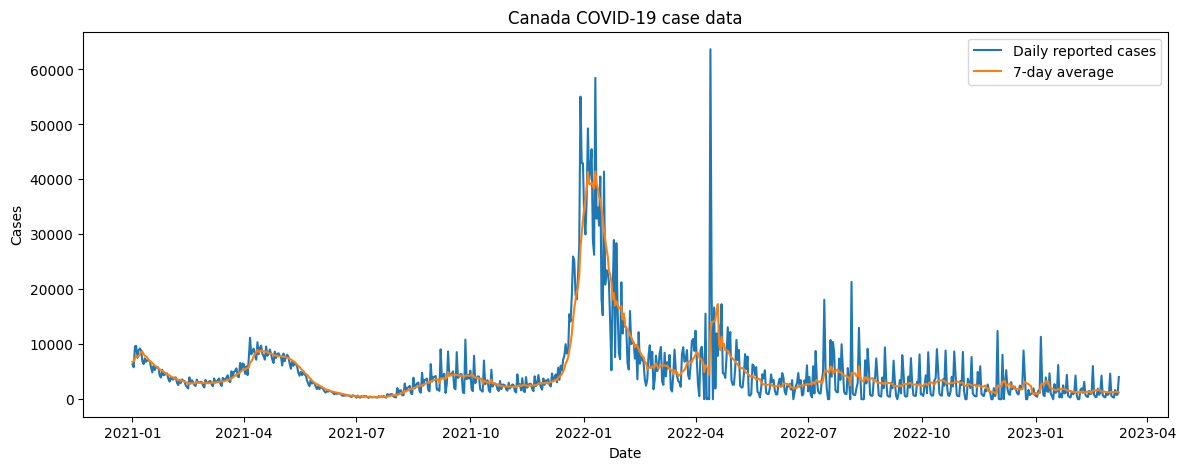

In [86]:
# Inspect Cleaned Inputs
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    model_data["Date"],
    model_data["DailyCasesClean"],
    label="Daily reported cases"
)

ax.plot(
    model_data["Date"],
    model_data["DailyCases7d"],
    label="7-day average"
)

ax.set_xlabel("Date")
ax.set_ylabel("Cases")
ax.set_title("Canada COVID-19 case data")

ax.legend()

plt.show()

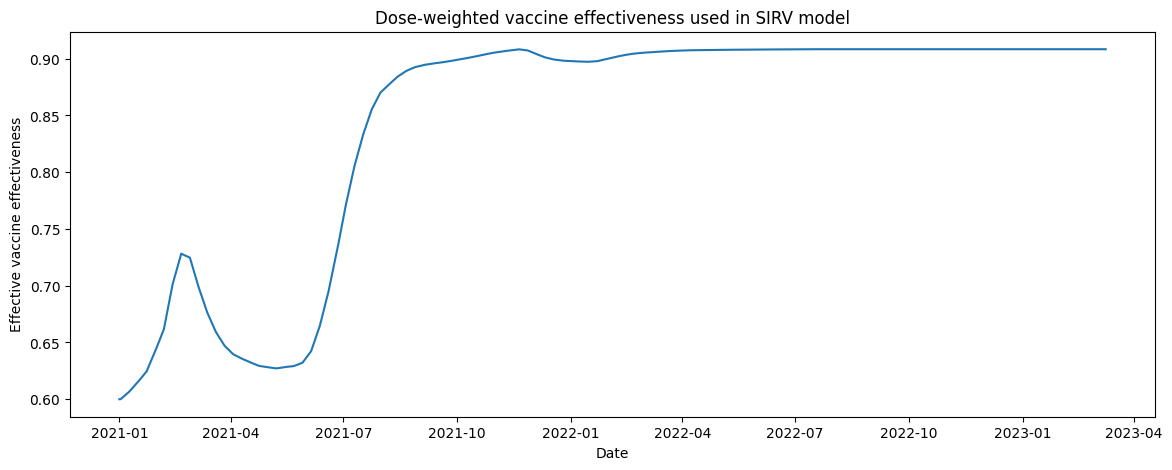

In [87]:
# Inspect vaccination effectiveness
plt.figure(figsize=(14, 5))

plt.plot(
    model_data["Date"],
    model_data["Epsilon"]
)

plt.xlabel("Date")
plt.ylabel("Effective vaccine effectiveness")
plt.title(
    "Dose-weighted vaccine effectiveness used in SIRV model"
)

plt.show()

In [88]:
# Fix gamma
gamma = 0.1

In [89]:
# ==========================================
# CELL 16
# Rolling SIRV model settings
# ==========================================

# Recovery rate
gamma = 0.1

# gamma = 1 / 10,
# so approximate infectious period = 10 days
D = 10

# One forecast window = 7 days
WINDOW_LEN = 7

# Weekly beta fitting range
BETA_MIN = 0.01
BETA_MAX = 1.50

# Initial optimizer guess
BETA_INITIAL = 0.30

# Use causal 7-day average to fit beta
FIT_COLUMN = "DailyCases7d"

# First forecast starts Jan 2.
# State on Jan 1 is therefore already known.
ROLLING_START = START_DATE + pd.Timedelta(days=1)

ROLLING_END = END_DATE

print("gamma =", gamma)
print("Infectious period =", D, "days")
print("Window length =", WINDOW_LEN, "days")

gamma = 0.1
Infectious period = 10 days
Window length = 7 days


In [90]:
# Initial conditions
# ==========================================
# CELL 17
# Weekly state reconstruction
# ==========================================

def latest_vaccination_info(on_date):
    """
    Return vaccination information that was
    available on or before on_date.

    This avoids using a future vaccination report
    when constructing the weekly starting state.
    """

    available = vacc_report[
        vacc_report["Date"] <= on_date
    ].copy()

    if len(available) == 0:
        return 0.0, EPSILON_1

    # Latest reported first-dose count
    latest_row = available.iloc[-1]

    vaccinated_population = (
        latest_row["numtotal_atleast1dose"]
    )

    if pd.isna(vaccinated_population):
        vaccinated_population = 0.0

    # Epsilon may become NaN after the PHAC
    # reporting-definition cutoff.
    # Use the most recent valid value.
    valid_epsilon = available[
        available["EpsilonReport"].notna()
    ]

    if len(valid_epsilon) > 0:
        epsilon_value = (
            valid_epsilon.iloc[-1]["EpsilonReport"]
        )
    else:
        epsilon_value = EPSILON_1

    return (
        float(vaccinated_population),
        float(epsilon_value)
    )

In [91]:
# Actual State Estimator
def estimate_weekly_state(on_date):
    """
    Estimate S, I, R, V at the END of on_date.

    The forecast therefore begins on on_date + 1.
    """

    # -----------------------------
    # 1. Population
    # -----------------------------

    population_row = population_daily[
        population_daily["Date"] == on_date
    ]

    if len(population_row) == 0:
        raise ValueError(
            f"No population value for {on_date}"
        )

    N0 = float(
        population_row.iloc[0]["Population"]
    )

    # -----------------------------
    # 2. Currently infectious
    # -----------------------------

    # Exactly the previous D days,
    # including on_date.
    infection_start = (
        on_date
        - pd.Timedelta(days=D - 1)
    )

    recent_cases = case_history[
        (case_history["Date"] >= infection_start) &
        (case_history["Date"] <= on_date)
    ]

    I0 = float(
        recent_cases["DailyCasesClean"].sum()
    )

    # -----------------------------
    # 3. Removed
    # -----------------------------

    case_row = case_history[
        case_history["Date"] == on_date
    ]

    if len(case_row) == 0:
        raise ValueError(
            f"No case value for {on_date}"
        )

    cumulative_confirmed = float(
        case_row.iloc[0]["Confirmed"]
    )

    # Following the rolling SIR idea:
    # cases outside the assumed infectious
    # period are treated as removed.
    R0 = max(
        cumulative_confirmed - I0,
        0.0
    )

    # -----------------------------
    # 4. Vaccination
    # -----------------------------

    (
        reported_vaccinated,
        epsilon0
    ) = latest_vaccination_info(
        on_date
    )

    # Remaining people not represented
    # by I or R
    remaining_population = max(
        N0 - I0 - R0,
        0.0
    )

    # Approximate vaccination coverage
    vaccination_fraction = np.clip(
        reported_vaccinated / N0,
        0.0,
        1.0
    )

    # Divide remaining population into:
    # V = vaccinated, still infection-eligible
    # S = unvaccinated susceptible
    V0 = (
        vaccination_fraction
        * remaining_population
    )

    S0 = (
        remaining_population
        - V0
    )

    return {
        "N": N0,
        "S": S0,
        "I": I0,
        "R": R0,
        "V": V0,
        "epsilon": epsilon0
    }

In [92]:
test_state = estimate_weekly_state(
    pd.Timestamp("2021-01-01")
)

test_state

print(
    test_state["S"]
    + test_state["I"]
    + test_state["R"]
    + test_state["V"]
)

print(
    test_state["N"]
)

38058291.0
38058291.0


In [93]:
from scipy.integrate import solve_ivp
def run_sirv_week(
    beta,
    gamma,
    N,
    S0,
    I0,
    R0,
    V0,
    epsilon,
    vaccination_flow
):
    """
    Numerically integrate the SIRV model over one week
    using scipy.integrate.solve_ivp (RK45).
    """

    vaccination_flow = np.asarray(
        vaccination_flow,
        dtype=float
    )

    days = len(vaccination_flow)

    # Arrays for daily compartment values
    S = np.zeros(days + 1)
    I = np.zeros(days + 1)
    R = np.zeros(days + 1)
    V = np.zeros(days + 1)

    predicted_cases = np.zeros(days)

    # Initial conditions
    S[0] = S0
    I[0] = I0
    R[0] = R0
    V[0] = V0

    # Solve one IVP for each day
    for day in range(days):

        daily_vaccination = max(
            float(vaccination_flow[day]),
            0.0
        )

        def sirv_ode(t, y):

            S_t, I_t, R_t, V_t, X_t = y

            # Infection of susceptible individuals
            infection_S = (
                beta
                * S_t
                * I_t
                / N
            )

            # Breakthrough infection
            infection_V = (
                (1 - epsilon)
                * beta
                * V_t
                * I_t
                / N
            )

            # Vaccination flow from S to V
            eligible = S_t + R_t

            if eligible > 0:
                vaccination_S = (
                    daily_vaccination
                    * S_t
                    / eligible
                )
            else:
                vaccination_S = 0.0

            # SIRV differential equations
            dSdt = (
                -infection_S
                - vaccination_S
            )

            dIdt = (
                infection_S
                + infection_V
                - gamma * I_t
            )

            dRdt = (
                gamma * I_t
            )

            dVdt = (
                vaccination_S
                - infection_V
            )

            # Cumulative incidence
            dXdt = (
                infection_S
                + infection_V
            )

            return [
                dSdt,
                dIdt,
                dRdt,
                dVdt,
                dXdt
            ]

        # State at beginning of this day
        y0 = [
            S[day],
            I[day],
            R[day],
            V[day],
            0.0
        ]

        # Integrate from beginning to end of the day
        solution = solve_ivp(
            sirv_ode,
            t_span=(0, 1),
            y0=y0,
            method="RK45",
            t_eval=[1.0],
            rtol=1e-6,
            atol=1e-8
        )

        if not solution.success:
            raise RuntimeError(
                solution.message
            )

        # State at end of the day
        S[day + 1] = solution.y[0, -1]
        I[day + 1] = solution.y[1, -1]
        R[day + 1] = solution.y[2, -1]
        V[day + 1] = solution.y[3, -1]

        # X gives infections accumulated during this day
        predicted_cases[day] = solution.y[4, -1]

    return predicted_cases, S, I, R, V

In [94]:
# Choose fitting data

# ==========================================
# CELL 19
# Fit beta for one historical week
# ==========================================

def fit_beta_for_week(
    state,
    actual_cases,
    vaccination_flow
):

    actual_cases = np.asarray(
        actual_cases,
        dtype=float
    )

    vaccination_flow = np.asarray(
        vaccination_flow,
        dtype=float
    )

    def residual_function(params):

        beta = params[0]

        (
            predicted,
            _,
            _,
            _,
            _
        ) = run_sirv_week(
            beta=beta,
            gamma=gamma,
            N=state["N"],
            S0=state["S"],
            I0=state["I"],
            R0=state["R"],
            V0=state["V"],
            epsilon=state["epsilon"],
            vaccination_flow=vaccination_flow
        )

        # Log-scale residuals
        residuals = (
            np.log1p(predicted)
            -
            np.log1p(actual_cases)
        )

        return residuals

    result = least_squares(
        residual_function,
        x0=[BETA_INITIAL],
        bounds=(
            [BETA_MIN],
            [BETA_MAX]
        )
    )

    return float(result.x[0])

In [95]:
# ==========================================
# CELL 20
# First pass: fit historical weekly betas
# ==========================================

weekly_beta_records = []

current_start = ROLLING_START

while (
    current_start
    + pd.Timedelta(days=WINDOW_LEN - 1)
    <= ROLLING_END
):

    reset_date = (
        current_start
        - pd.Timedelta(days=1)
    )

    state = estimate_weekly_state(
        reset_date
    )

    window_end = (
        current_start
        + pd.Timedelta(days=WINDOW_LEN)
    )

    window = model_data[
        (model_data["Date"] >= current_start) &
        (model_data["Date"] < window_end)
    ].copy()

    if len(window) != WINDOW_LEN:
        current_start += pd.Timedelta(
            days=WINDOW_LEN
        )
        continue

    actual_cases = (
        window[FIT_COLUMN]
        .to_numpy(dtype=float)
    )

    actual_vaccination_flow = (
        window["DailyVaccinationFlow"]
        .to_numpy(dtype=float)
    )

    beta_week = fit_beta_for_week(
        state=state,
        actual_cases=actual_cases,
        vaccination_flow=
            actual_vaccination_flow
    )

    weekly_beta_records.append({
        "WeekStart": current_start,
        "ResetDate": reset_date,
        "Beta": beta_week,
        "N0": state["N"],
        "S0": state["S"],
        "I0": state["I"],
        "R0": state["R"],
        "V0": state["V"],
        "Epsilon": state["epsilon"],
        "MeanVaccinationFlow":
            actual_vaccination_flow.mean()
    })

    current_start += pd.Timedelta(
        days=WINDOW_LEN
    )

weekly_betas = pd.DataFrame(
    weekly_beta_records
)

print(
    "Number of weekly betas:",
    len(weekly_betas)
)

weekly_betas.head(10)

Number of weekly betas: 113


,WeekStart,ResetDate,Beta,N0,S0,I0,R0,V0,Epsilon,MeanVaccinationFlow
0,2021-01-02,2021-01-01,0.114356,3.805829e+07,3.741625e+07,66604.0,529978.0,4.545611e+04,0.600000,17255.673469
1,2021-01-09,2021-01-08,0.098310,3.806472e+07,3.732731e+07,80758.0,575540.0,8.110705e+04,0.600000,45313.489796
2,2021-01-16,2021-01-15,0.087654,3.807114e+07,3.715290e+07,75608.0,629266.0,2.133680e+05,0.606664,32877.612245
3,2021-01-23,2021-01-22,0.088853,3.807757e+07,3.677937e+07,60450.0,683815.0,5.539330e+05,0.615162,14552.571429
4,2021-01-30,2021-01-29,0.089349,3.808400e+07,3.654825e+07,49086.0,726920.0,7.597433e+05,0.624472,6875.081633
5,2021-02-06,2021-02-05,0.091826,3.809042e+07,3.644717e+07,39824.0,762223.0,8.412033e+05,0.642327,9631.510204
6,2021-02-13,2021-02-12,0.093964,3.809685e+07,3.639053e+07,33792.0,790553.0,8.819785e+05,0.661698,15362.408163
7,2021-02-20,2021-02-19,0.103227,3.810328e+07,3.630725e+07,30428.0,814050.0,9.515441e+05,0.701079,38433.591837
8,2021-02-27,2021-02-26,0.102507,3.810970e+07,3.618236e+07,30361.0,835022.0,1.061958e+06,0.728188,63986.693878
9,2021-03-06,2021-03-05,0.107565,3.811613e+07,3.588057e+07,30038.0,856056.0,1.349469e+06,0.724708,88670.428571


In [96]:
# ==========================================
# CELL 21
# Out-of-sample rolling forecast
# ==========================================

forecast_records = []

for i in range(
    1,
    len(weekly_betas)
):

    # Week being predicted
    this_week_start = (
        weekly_betas.iloc[i]["WeekStart"]
    )

    reset_date = (
        this_week_start
        - pd.Timedelta(days=1)
    )

    # -----------------------------
    # Current observed state
    # -----------------------------

    state = estimate_weekly_state(
        reset_date
    )

    # -----------------------------
    # Use ONLY previous week's beta
    # -----------------------------

    beta_forecast = float(
        weekly_betas.iloc[i - 1]["Beta"]
    )

    # -----------------------------
    # Forecast vaccination flow
    # -----------------------------

    # Persistence assumption:
    # next week's first-dose flow
    # equals previous week's mean.
    previous_vaccination_flow = float(
        weekly_betas
        .iloc[i - 1]
        ["MeanVaccinationFlow"]
    )

    forecast_vaccination_flow = np.full(
        WINDOW_LEN,
        previous_vaccination_flow,
        dtype=float
    )

    # -----------------------------
    # Forecast 7 days
    # -----------------------------

    (
        predicted_cases,
        S,
        I,
        R,
        V
    ) = run_sirv_week(
        beta=beta_forecast,
        gamma=gamma,
        N=state["N"],
        S0=state["S"],
        I0=state["I"],
        R0=state["R"],
        V0=state["V"],
        epsilon=state["epsilon"],
        vaccination_flow=
            forecast_vaccination_flow
    )

    # -----------------------------
    # Reality — used only AFTER
    # forecast has been generated
    # -----------------------------

    this_week_end = (
        this_week_start
        + pd.Timedelta(days=WINDOW_LEN)
    )

    actual_window = model_data[
        (
            model_data["Date"]
            >= this_week_start
        )
        &
        (
            model_data["Date"]
            < this_week_end
        )
    ].copy()

    if len(actual_window) != WINDOW_LEN:
        continue

    actual_cases = (
        actual_window[FIT_COLUMN]
        .to_numpy(dtype=float)
    )

    dates = (
        actual_window["Date"]
        .to_numpy()
    )

    # Current week's fitted beta is saved
    # only for later comparison.
    # It was NOT used for this forecast.
    actual_fitted_beta = float(
        weekly_betas.iloc[i]["Beta"]
    )

    for day in range(WINDOW_LEN):

        forecast_records.append({
            "Date": dates[day],
            "WeekStart":
                this_week_start,

            "PredictedCases":
                predicted_cases[day],

            "ActualCases":
                actual_cases[day],

            "BetaForecast":
                beta_forecast,

            "BetaFittedThisWeek":
                actual_fitted_beta,

            "VaccinationFlowForecast":
                previous_vaccination_flow,

            "Epsilon":
                state["epsilon"]
        })




In [97]:
# ==========================================
# CELL 22
# Forecast accuracy
# ==========================================

forecast_results = pd.DataFrame(
    forecast_records
)

forecast_results["Error"] = (
    forecast_results["PredictedCases"]
    -
    forecast_results["ActualCases"]
)

forecast_results["AbsoluteError"] = (
    forecast_results["Error"].abs()
)

forecast_results["SquaredError"] = (
    forecast_results["Error"] ** 2
)

MAE = (
    forecast_results[
        "AbsoluteError"
    ].mean()
)

RMSE = np.sqrt(
    forecast_results[
        "SquaredError"
    ].mean()
)

print(
    "Rolling forecast MAE:",
    MAE
)

print(
    "Rolling forecast RMSE:",
    RMSE
)

forecast_results.head(14)

Rolling forecast MAE: 896.6898092613261
Rolling forecast RMSE: 2272.9897216291643


,Date,WeekStart,PredictedCases,ActualCases,BetaForecast,BetaFittedThisWeek,VaccinationFlowForecast,Epsilon,Error,AbsoluteError,SquaredError
0,2021-01-09,2021-01-09,9117.356888,8684.571429,0.114356,0.098310,17255.673469,0.600000,432.785459,432.785459,1.873033e+05
1,2021-01-10,2021-01-09,9224.300758,8224.428571,0.114356,0.098310,17255.673469,0.600000,999.872187,999.872187,9.997444e+05
2,2021-01-11,2021-01-09,9331.926351,7896.285714,0.114356,0.098310,17255.673469,0.600000,1435.640637,1435.640637,2.061064e+06
3,2021-01-12,2021-01-09,9440.225179,7792.714286,0.114356,0.098310,17255.673469,0.600000,1647.510893,1647.510893,2.714292e+06
4,2021-01-13,2021-01-09,9549.188403,7532.714286,0.114356,0.098310,17255.673469,0.600000,2016.474117,2016.474117,4.066168e+06
5,2021-01-14,2021-01-09,9658.806833,7216.714286,0.114356,0.098310,17255.673469,0.600000,2442.092547,2442.092547,5.963816e+06
6,2021-01-15,2021-01-09,9769.070924,6939.428571,0.114356,0.098310,17255.673469,0.600000,2829.642352,2829.642352,8.006876e+06
7,2021-01-16,2021-01-16,7252.759058,6783.857143,0.098310,0.087654,45313.489796,0.606664,468.901915,468.901915,2.198690e+05
8,2021-01-17,2021-01-16,7217.645810,6566.714286,0.098310,0.087654,45313.489796,0.606664,650.931524,650.931524,4.237118e+05
9,2021-01-18,2021-01-16,7182.070035,6370.285714,0.098310,0.087654,45313.489796,0.606664,811.784321,811.784321,6.589938e+05


In [98]:
# ==========================================
# CELL 23
# 2023 performance
# ==========================================

forecast_2023 = forecast_results[
    forecast_results["Date"]
    >= pd.Timestamp("2023-01-01")
]

if len(forecast_2023) > 0:

    MAE_2023 = (
        forecast_2023[
            "AbsoluteError"
        ].mean()
    )

    RMSE_2023 = np.sqrt(
        forecast_2023[
            "SquaredError"
        ].mean()
    )

    print(
        "2023 MAE:",
        MAE_2023
    )

    print(
        "2023 RMSE:",
        RMSE_2023
    )

2023 MAE: 594.8884220234057
2023 RMSE: 809.7823972991802


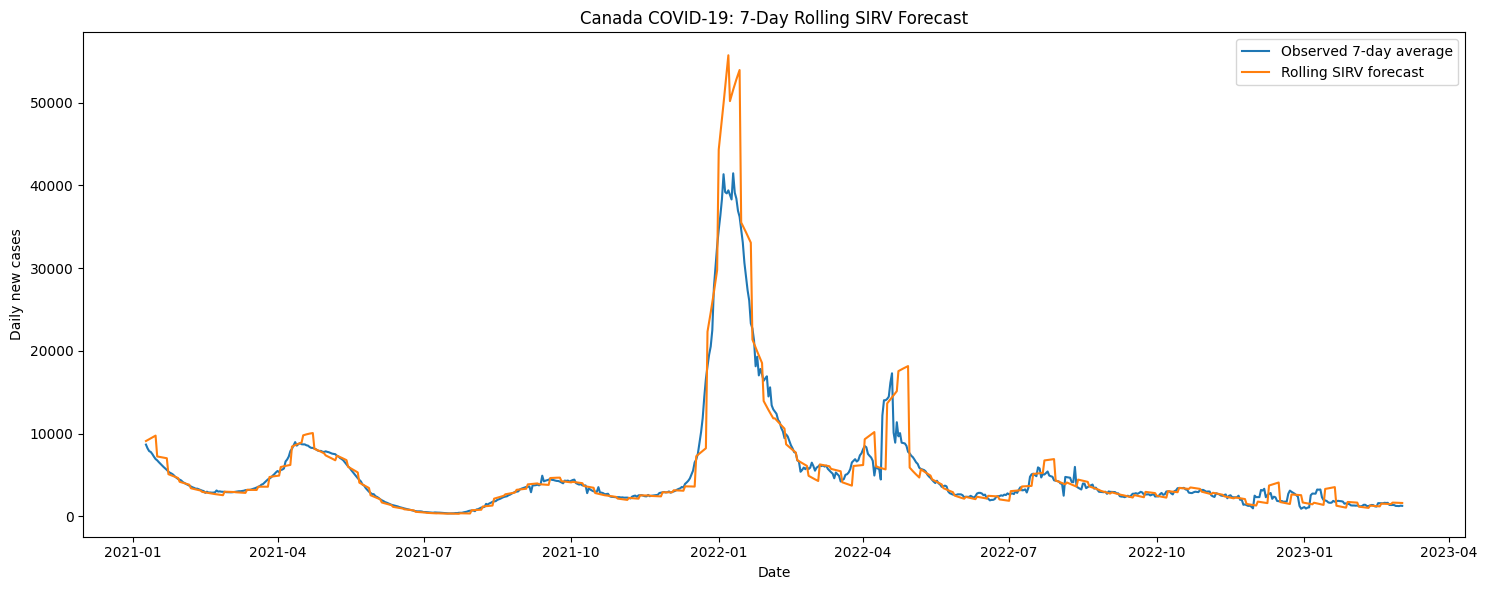

In [99]:
# ==========================================
# CELL 24
# Rolling forecast vs observed
# ==========================================

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    forecast_results["Date"],
    forecast_results["ActualCases"],
    label="Observed 7-day average"
)

plt.plot(
    forecast_results["Date"],
    forecast_results["PredictedCases"],
    label="Rolling SIRV forecast"
)

plt.xlabel("Date")
plt.ylabel("Daily new cases")

plt.title(
    "Canada COVID-19: "
    "7-Day Rolling SIRV Forecast"
)

plt.legend()
plt.tight_layout()

plt.show()

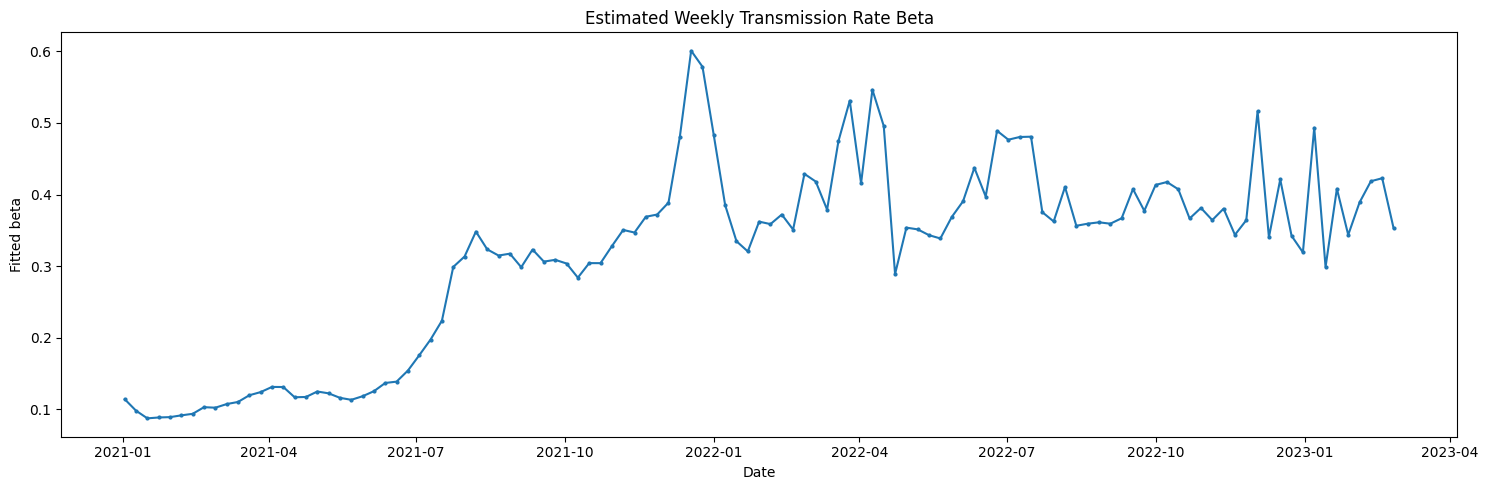

In [100]:
# ==========================================
# CELL 25
# Weekly beta over time
# ==========================================

plt.figure(
    figsize=(15, 5)
)

plt.plot(
    weekly_betas["WeekStart"],
    weekly_betas["Beta"],
    marker="o",
    markersize=2
)

plt.xlabel("Date")
plt.ylabel("Fitted beta")

plt.title(
    "Estimated Weekly Transmission Rate Beta"
)

plt.tight_layout()
plt.show()

In [101]:
# ==========================================
# CELL 26
# Weekly beta summary
# ==========================================

print(
    weekly_betas["Beta"].describe()
)

print(
    "\nMinimum beta:"
)

print(
    weekly_betas.loc[
        weekly_betas["Beta"].idxmin(),
        ["WeekStart", "Beta"]
    ]
)

print(
    "\nMaximum beta:"
)

print(
    weekly_betas.loc[
        weekly_betas["Beta"].idxmax(),
        ["WeekStart", "Beta"]
    ]
)

count    113.000000
mean       0.317155
std        0.129537
min        0.087654
25%        0.223940
50%        0.350582
75%        0.390593
max        0.600728
Name: Beta, dtype: float64

Minimum beta:
WeekStart    2021-01-16 00:00:00
Beta                    0.087654
Name: 2, dtype: object

Maximum beta:
WeekStart    2021-12-18 00:00:00
Beta                    0.600728
Name: 50, dtype: object


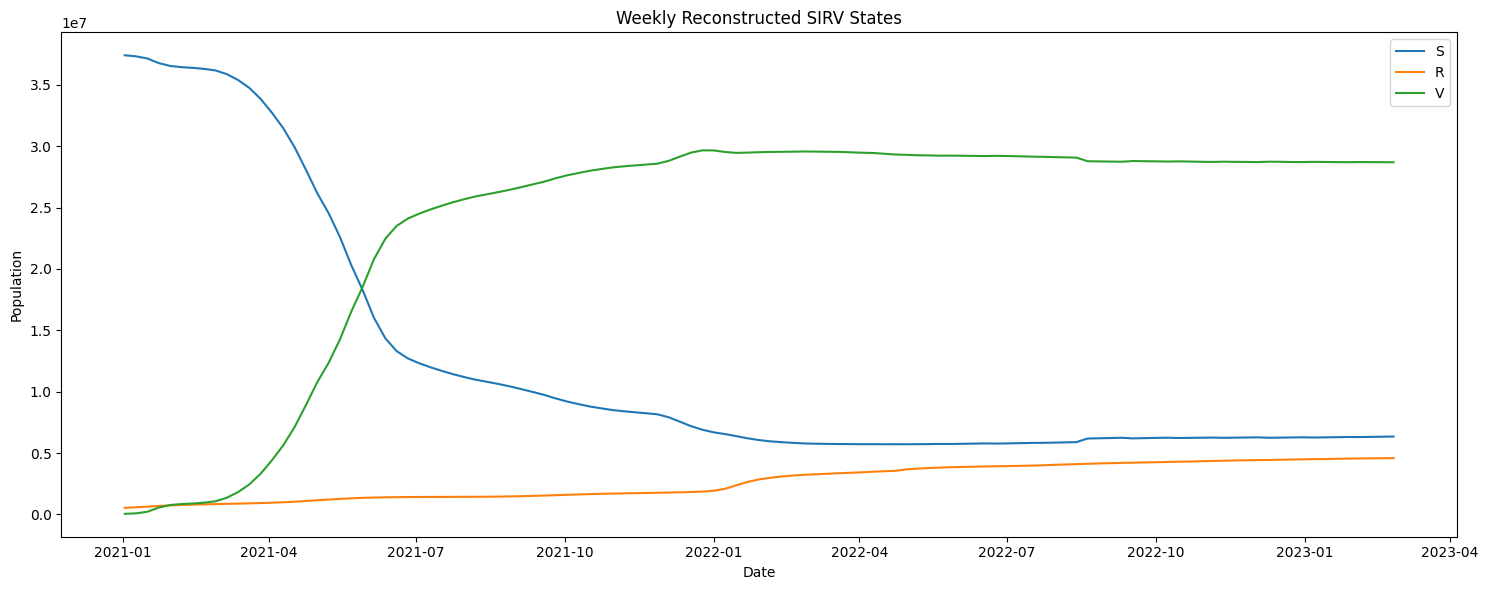

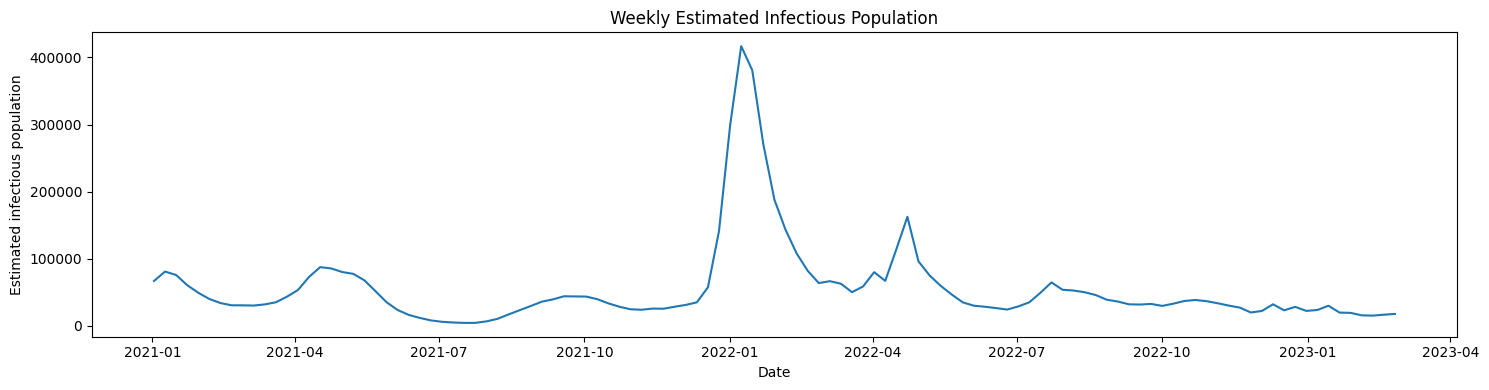

In [102]:
# ==========================================
# CELL 27
# Weekly reconstructed states
# ==========================================

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    weekly_betas["WeekStart"],
    weekly_betas["S0"],
    label="S"
)

plt.plot(
    weekly_betas["WeekStart"],
    weekly_betas["R0"],
    label="R"
)

plt.plot(
    weekly_betas["WeekStart"],
    weekly_betas["V0"],
    label="V"
)

plt.xlabel("Date")
plt.ylabel("Population")

plt.title(
    "Weekly Reconstructed SIRV States"
)

plt.legend()
plt.tight_layout()

plt.show()

plt.figure(
    figsize=(15, 4)
)

plt.plot(
    weekly_betas["WeekStart"],
    weekly_betas["I0"]
)

plt.xlabel("Date")
plt.ylabel("Estimated infectious population")

plt.title(
    "Weekly Estimated Infectious Population"
)

plt.tight_layout()

plt.show()

In [103]:
# ==========================================
# CELL 28
# Save rolling-model outputs
# ==========================================

weekly_betas.to_csv(
    data_path
    + "weekly_beta_estimates.csv",
    index=False
)

forecast_results.to_csv(
    data_path
    + "rolling_sirv_forecast.csv",
    index=False
)

print("Saved.")

Saved.
